# iris.py 動作確認ノートブック

Phase A で実装した `iris.py` (`AnalyzeIris` クラス) が、模範解答ノートブックの呼び出しを全てエラーなく実行できることを確認するためのノートブックです。

## 使い方

1. このノートブックと `iris.py` を同じディレクトリに置く
2. 上から順にセルを実行する
3. 模範解答 `analyze_iris` ノートブックと並べて、出力を見比べる

## 比較観点

- 数値が完全一致しないセルがあるが、これは **sklearn のバージョン差**による微小な数値ぶれ。ロジックは正しい。
- 完全一致するもの: PCA `components_`、DBSCAN クラスタラベル、各メソッドの構造


## 0. 環境設定


In [4]:
# auto reload
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
# pandas display setting
import pandas as pd
pd.set_option("display.max_rows", None)
import warnings
warnings.filterwarnings('ignore')

In [6]:
from iris_comp import AnalyzeIris

## 1. 基本: データの取得と相関分析


In [7]:
iris = AnalyzeIris()
iris.get()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Label
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
5,5.4,3.9,1.7,0.4,0
6,4.6,3.4,1.4,0.3,0
7,5.0,3.4,1.5,0.2,0
8,4.4,2.9,1.4,0.2,0
9,4.9,3.1,1.5,0.1,0


In [8]:
# 変数間の相関係数を確認する
iris.get_correlation()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.000000,-0.117570,0.871754,0.817941
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126
petal length (cm),0.871754,-0.428440,1.000000,0.962865
petal width (cm),0.817941,-0.366126,0.962865,1.000000


## 2. ペアプロット

**チェックポイント**: `pair_plot(diag_kind='kde')` でエラーが出ないこと(元コードの引数名 `diag` を `diag_kind` に修正済み)。


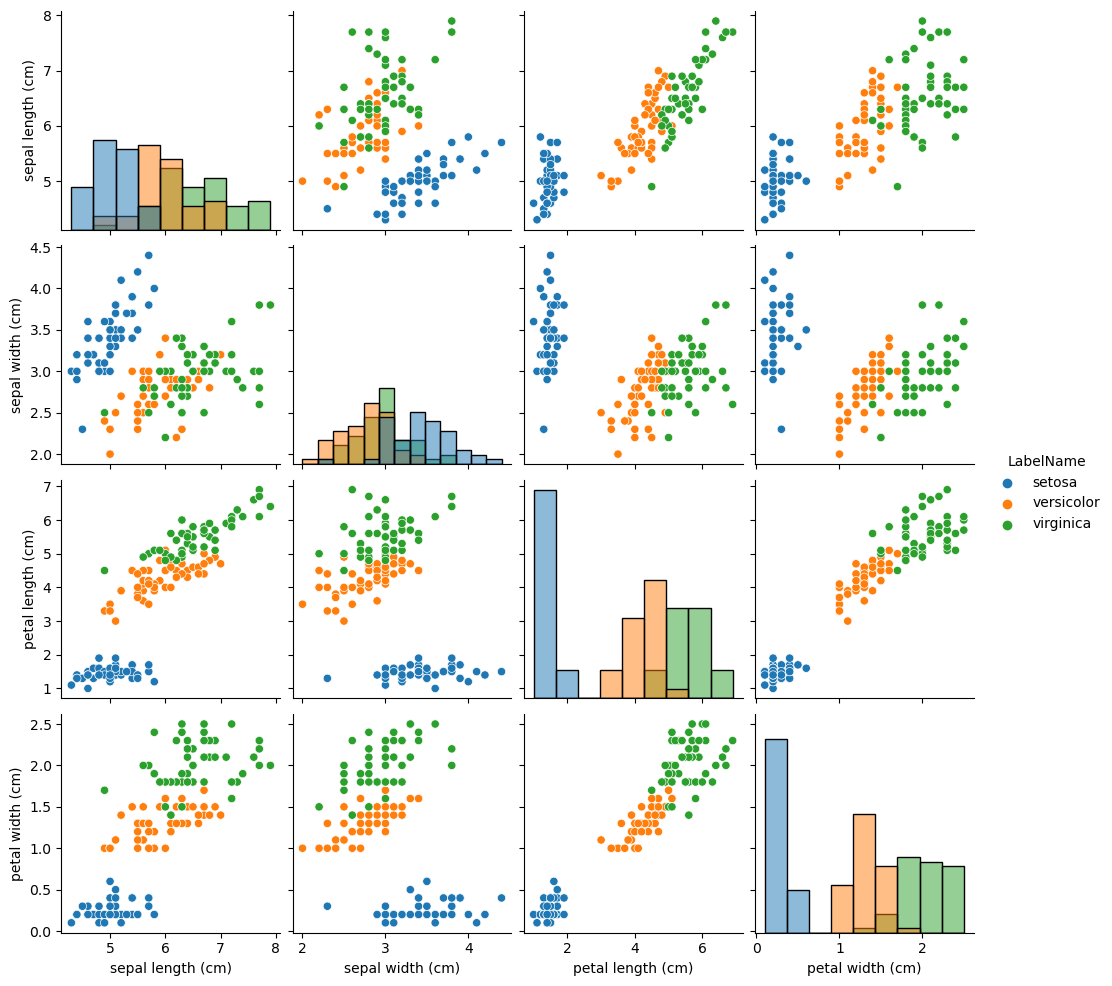

In [9]:
# seabornを使ってpair_plotする
iris.pair_plot()

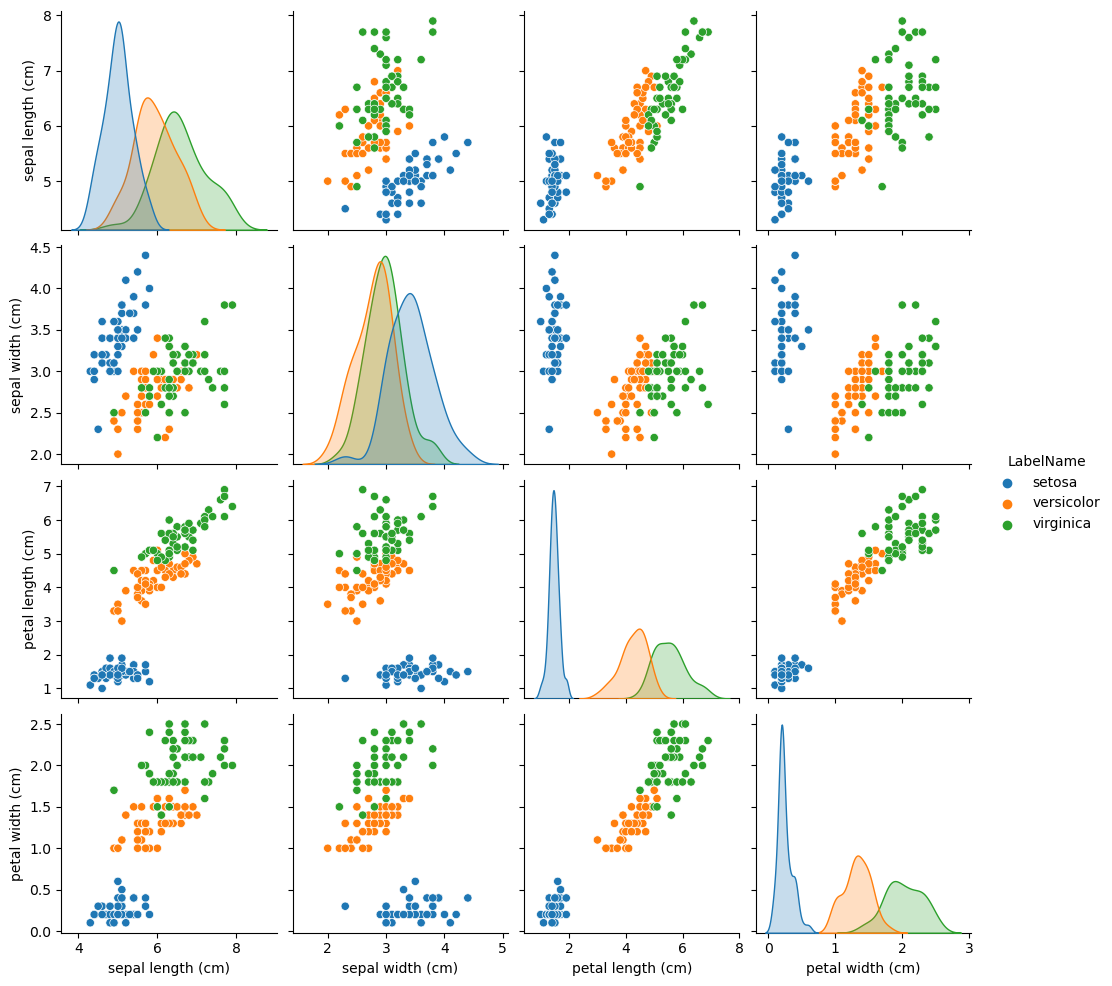

In [10]:
# ペアプロット対角成分をカーネル密度推定してプロットする
iris.pair_plot(diag_kind="kde")

## 3. 教師あり学習(交差検証)

**チェックポイント**: 

- 出力ヘッダが `=== ModelName ===` (`==` から `===` に変更済み)
- `LinearRegression` がモデル一覧に含まれている
- 計9モデルの結果が表示される


In [11]:
iris.all_supervised(n_neighbors=4)

=== LogisticRegression ===
test score: 0.967, train score: 0.967
test score: 1.000, train score: 0.967
test score: 0.933, train score: 0.983
test score: 0.967, train score: 0.983
test score: 1.000, train score: 0.975

=== LinearSVC ===
test score: 1.000, train score: 0.950
test score: 1.000, train score: 0.958
test score: 0.933, train score: 0.975
test score: 0.900, train score: 0.983
test score: 1.000, train score: 0.967

=== SVC ===
test score: 0.967, train score: 0.983
test score: 0.967, train score: 0.958
test score: 0.967, train score: 0.983
test score: 0.933, train score: 0.983
test score: 1.000, train score: 0.958

=== DecisionTreeClassifier ===
test score: 0.967, train score: 1.000
test score: 0.967, train score: 1.000
test score: 0.900, train score: 1.000
test score: 0.967, train score: 1.000
test score: 1.000, train score: 1.000

=== KNeighborsClassifier ===
test score: 0.967, train score: 0.958
test score: 0.967, train score: 0.958
test score: 0.967, train score: 0.958
test 

In [12]:
iris.get_supervised()

,LogisticRegression,LinearSVC,SVC,DecisionTreeClassifier,KNeighborsClassifier,LinearRegression,RandomForestClassifier,GradientBoostingClassifier,MLPClassifier
0,0.966667,1.000000,0.966667,0.966667,0.966667,0.000000,0.966667,0.966667,1.000000
1,1.000000,1.000000,0.966667,0.966667,0.966667,0.851249,0.966667,0.966667,1.000000
2,0.933333,0.933333,0.966667,0.900000,0.966667,0.000000,0.933333,0.900000,0.966667
3,0.966667,0.900000,0.933333,0.966667,0.966667,0.761554,0.966667,0.966667,0.933333
4,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000


In [13]:
df_score = iris.get_supervised().describe()
df_score

,LogisticRegression,LinearSVC,SVC,DecisionTreeClassifier,KNeighborsClassifier,LinearRegression,RandomForestClassifier,GradientBoostingClassifier,MLPClassifier
count,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
mean,0.973333,0.966667,0.966667,0.960000,0.973333,0.322561,0.966667,0.960000,0.980000
std,0.027889,0.047140,0.023570,0.036515,0.014907,0.442821,0.023570,0.036515,0.029814
min,0.933333,0.900000,0.933333,0.900000,0.966667,0.000000,0.933333,0.900000,0.933333
25%,0.966667,0.933333,0.966667,0.966667,0.966667,0.000000,0.966667,0.966667,0.966667
50%,0.966667,1.000000,0.966667,0.966667,0.966667,0.000000,0.966667,0.966667,1.000000
75%,1.000000,1.000000,0.966667,0.966667,0.966667,0.761554,0.966667,0.966667,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,0.851249,1.000000,1.000000,1.000000


In [14]:
best_method, best_score = iris.best_supervised()
print("BestMethod is ", best_method, " : ", "{0:0.4f}".format(best_score))

BestMethod is  MLPClassifier  :  0.9800


## 4. 木ベースモデルの特徴量重要度・決定木可視化


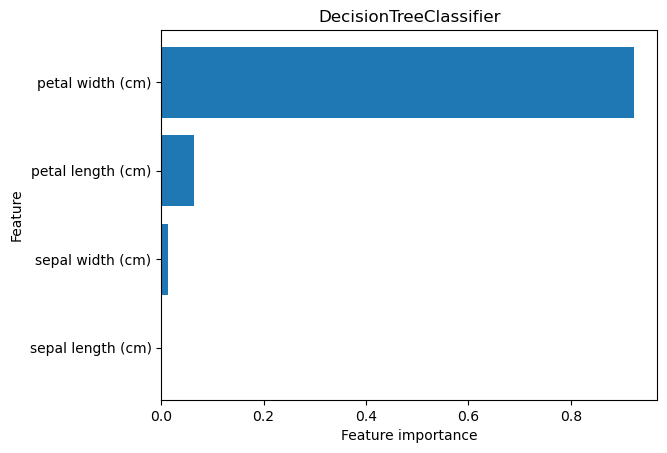

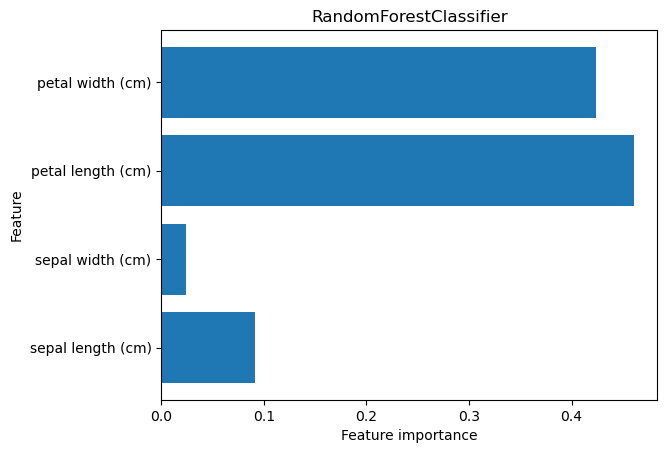

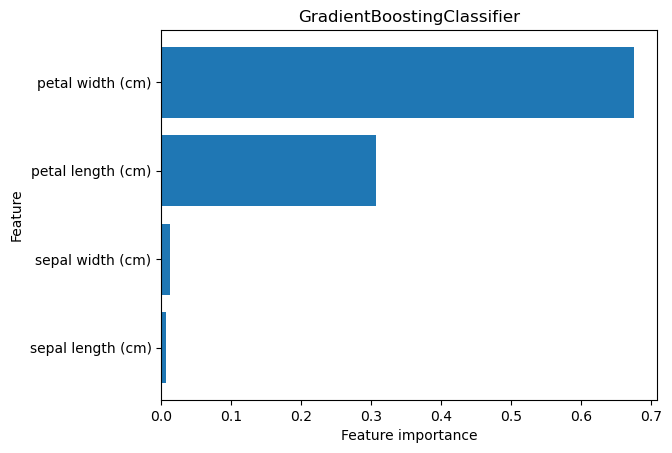

In [15]:
iris.plot_feature_importances_all()

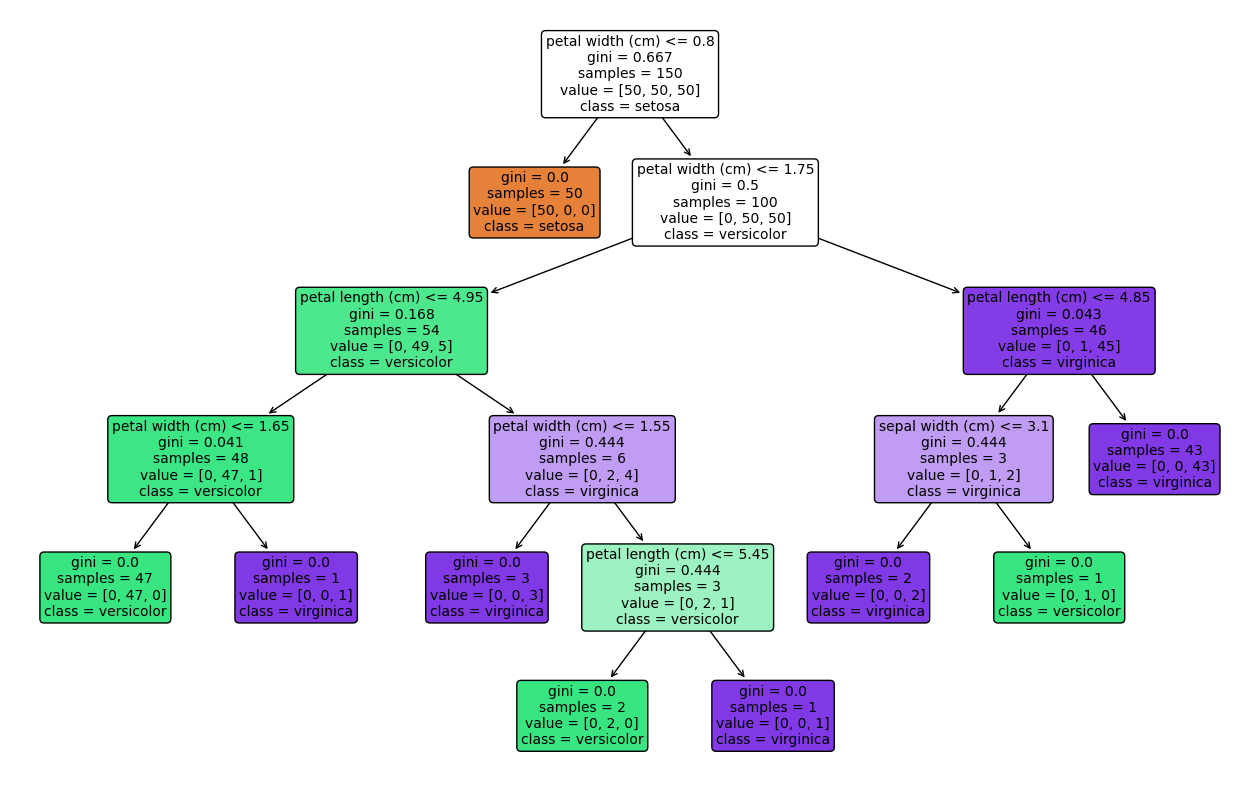

In [16]:
graph = iris.visualize_decision_tree()

## 5. スケーリング比較(Phase A 新規実装)

**チェックポイント**:

- 各 fold ごとに 5 種スケーラー × LinearSVC の test/train スコアが表示される
- `=========` 区切りで 5 fold分の結果が出力される
- 各 fold で散布図(2x3 レイアウト)が表示される
- 戻り値が DataFrame(25行 × 4列: fold/scaler/test_score/train_score)

**模範解答との数値差**: sklearn のバージョン差により 1 サンプル分(115/120 vs 114/120)の微小な差が出る。これは LinearSVC の数値計算の違いに起因する既知の挙動差で、実装のバグではない。


Original       :  test score: 1.000      train score: 0.950     
MinMaxScaler   :  test score: 0.833      train score: 0.942     
StandardScaler :  test score: 0.933      train score: 0.950     
RobusScaler    :  test score: 0.900      train score: 0.950     
Normalizer     :  test score: 0.900      train score: 0.908     


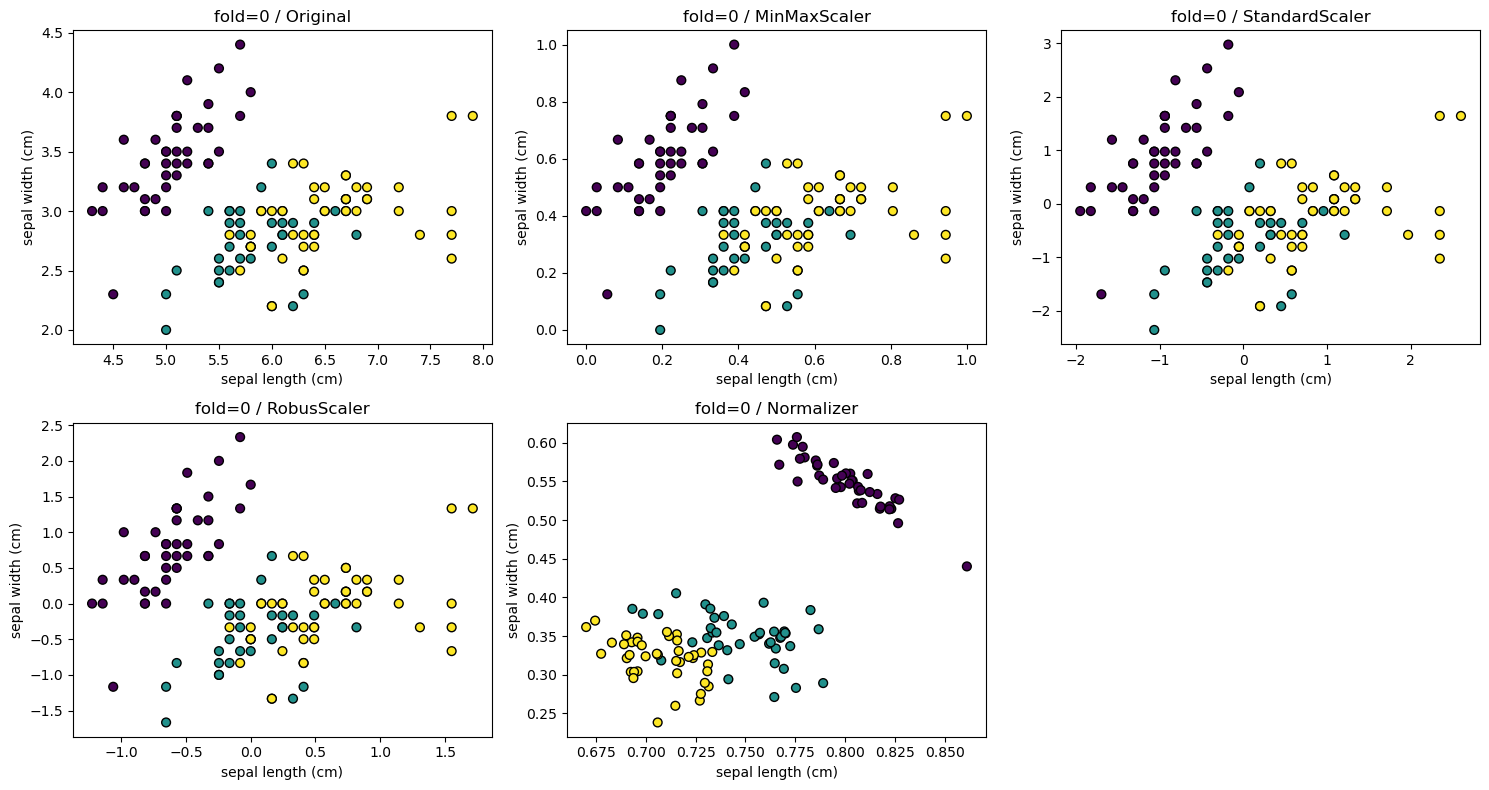

Original       :  test score: 1.000      train score: 0.958     
MinMaxScaler   :  test score: 0.967      train score: 0.942     
StandardScaler :  test score: 0.967      train score: 0.942     
RobusScaler    :  test score: 0.967      train score: 0.933     
Normalizer     :  test score: 0.933      train score: 0.908     


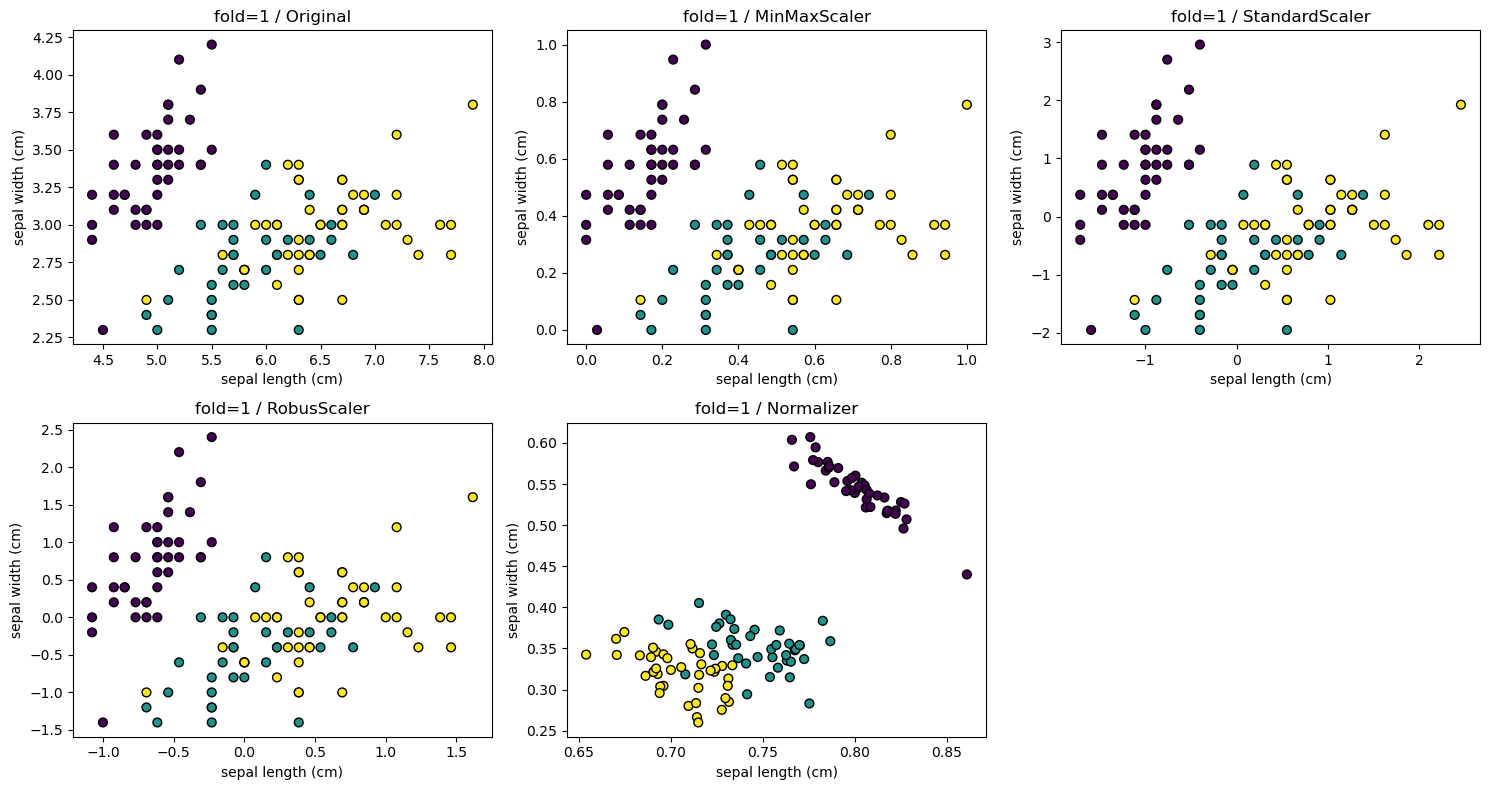

Original       :  test score: 0.933      train score: 0.975     
MinMaxScaler   :  test score: 0.933      train score: 0.942     
StandardScaler :  test score: 0.933      train score: 0.950     
RobusScaler    :  test score: 0.933      train score: 0.950     
Normalizer     :  test score: 0.867      train score: 0.925     


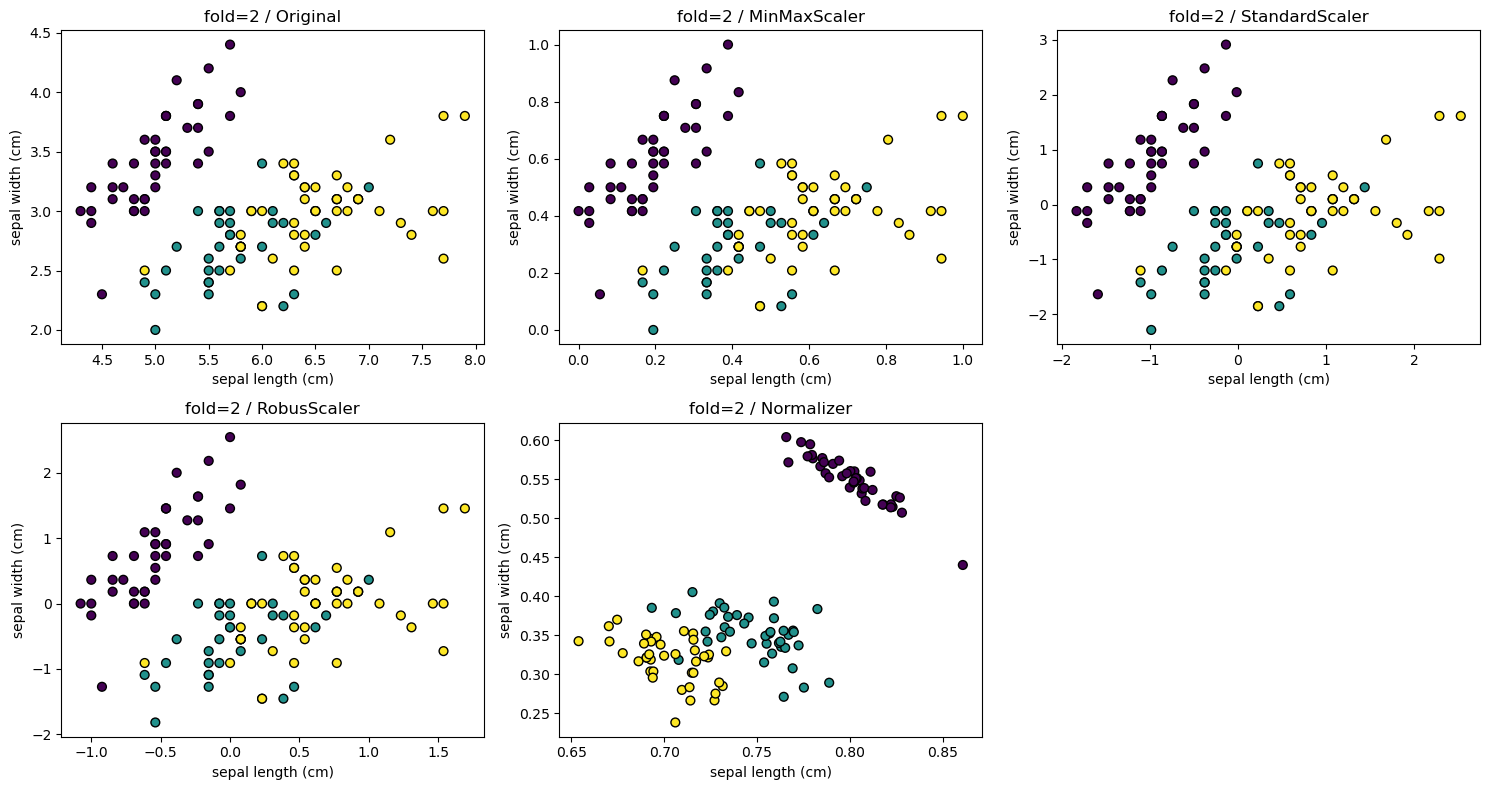

Original       :  test score: 0.900      train score: 0.983     
MinMaxScaler   :  test score: 0.833      train score: 0.967     
StandardScaler :  test score: 0.867      train score: 0.958     
RobusScaler    :  test score: 0.867      train score: 0.958     
Normalizer     :  test score: 0.900      train score: 0.908     


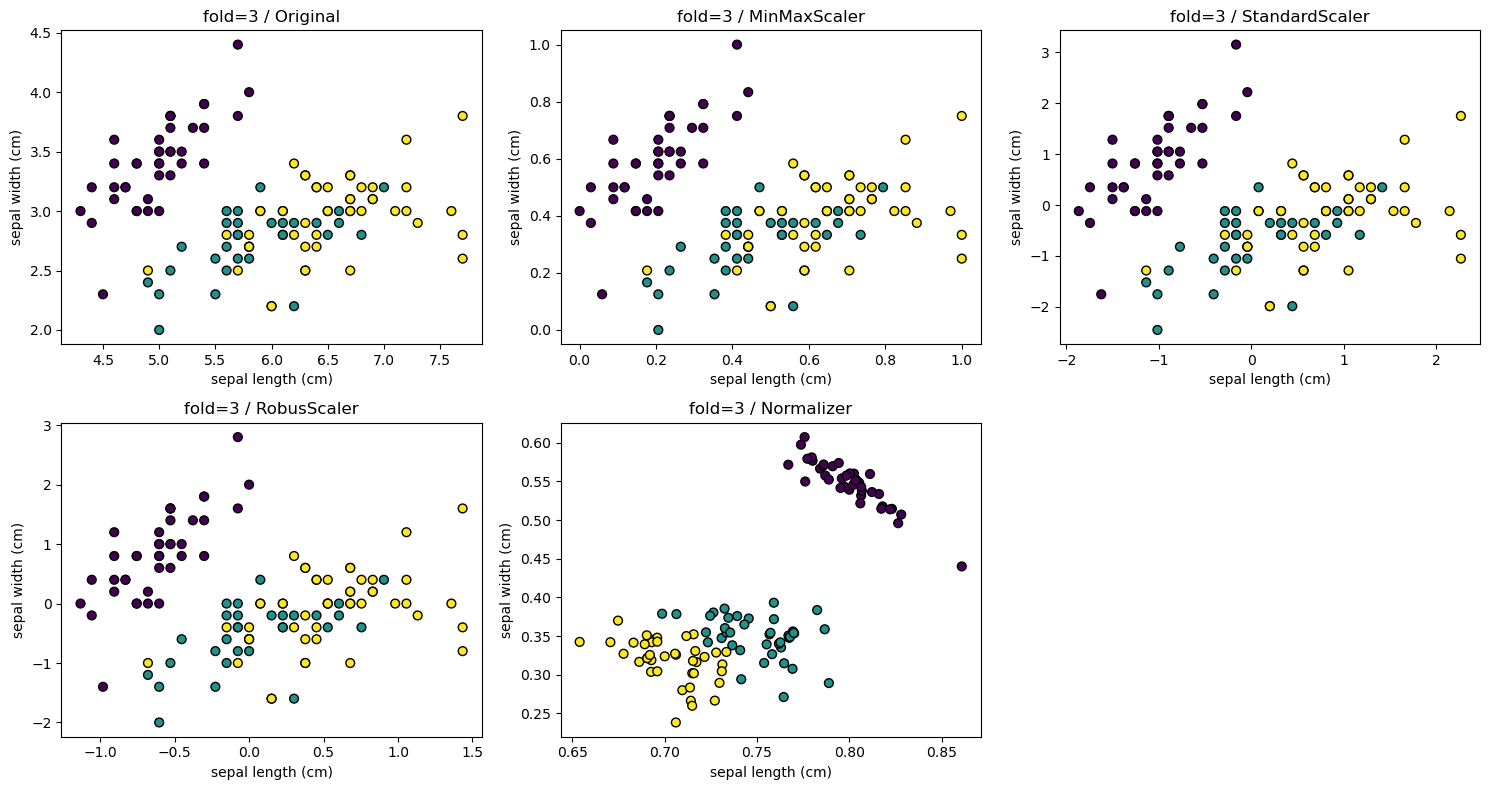

Original       :  test score: 1.000      train score: 0.967     
MinMaxScaler   :  test score: 1.000      train score: 0.933     
StandardScaler :  test score: 0.967      train score: 0.942     
RobusScaler    :  test score: 0.967      train score: 0.933     
Normalizer     :  test score: 0.900      train score: 0.900     


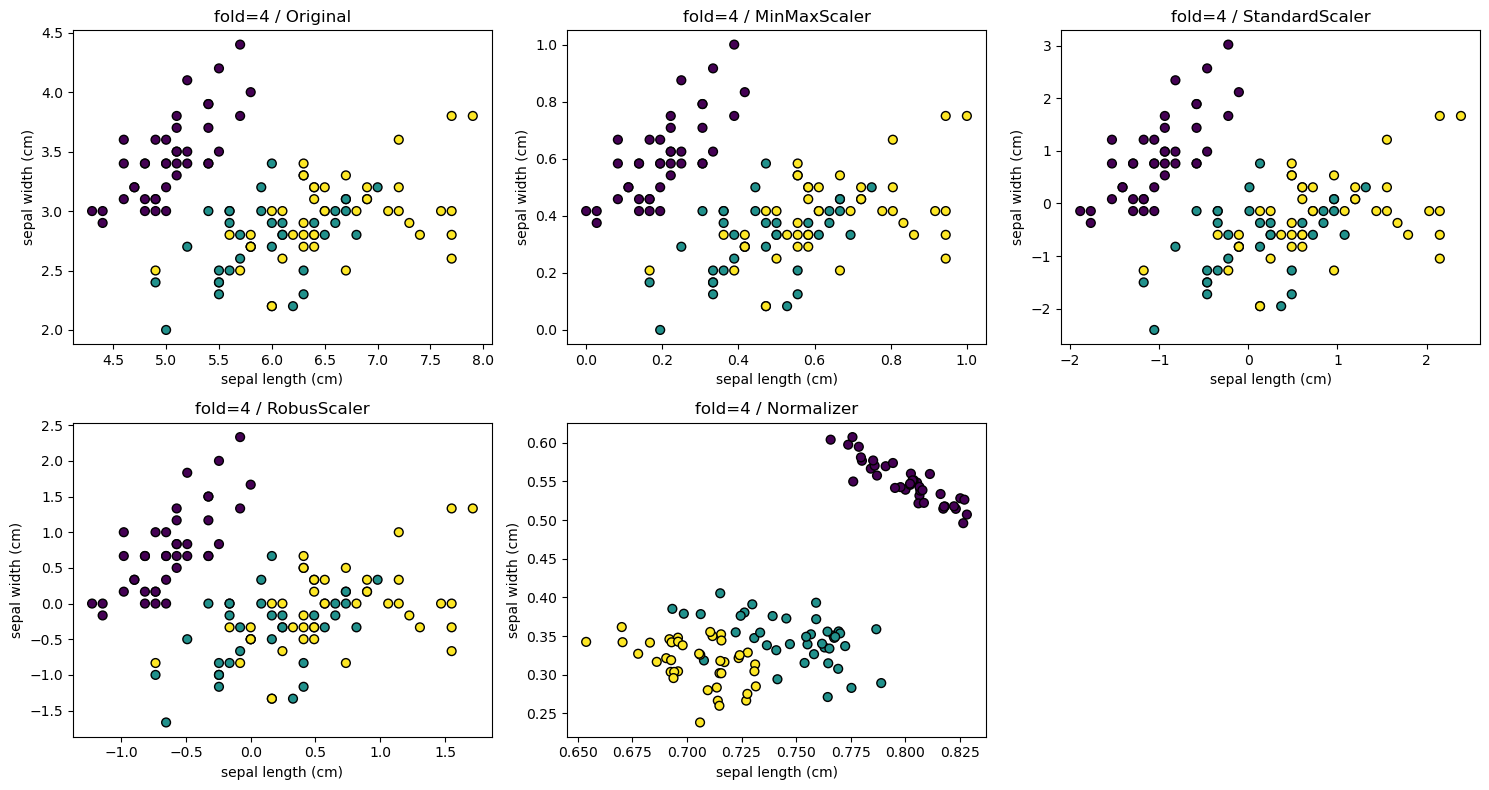

In [17]:
# 5-foldで、それぞれの要素に対するスケーリングと、そのときのLinearSVCの結果を一覧
train_data = iris.plot_scaled_data()

In [18]:
# 戻り値を確認(Phase A の追加機能: 結果を再利用できるよう DataFrame で返す)
train_data

,fold,scaler,test_score,train_score
0,0,Original,1.000000,0.950000
1,0,MinMaxScaler,0.833333,0.941667
2,0,StandardScaler,0.933333,0.950000
3,0,RobusScaler,0.900000,0.950000
4,0,Normalizer,0.900000,0.908333
5,1,Original,1.000000,0.958333
6,1,MinMaxScaler,0.966667,0.941667
7,1,StandardScaler,0.966667,0.941667
8,1,RobusScaler,0.966667,0.933333
9,1,Normalizer,0.933333,0.908333


## 6. 次元削減(PCA / NMF / t-SNE)

**チェックポイント**: 

- `plot_pca` の戻り値タプル `(X_scaled, df_pca, X_pca)` が正しい型
- `X_pca.components_` が **模範解答と完全一致** すること


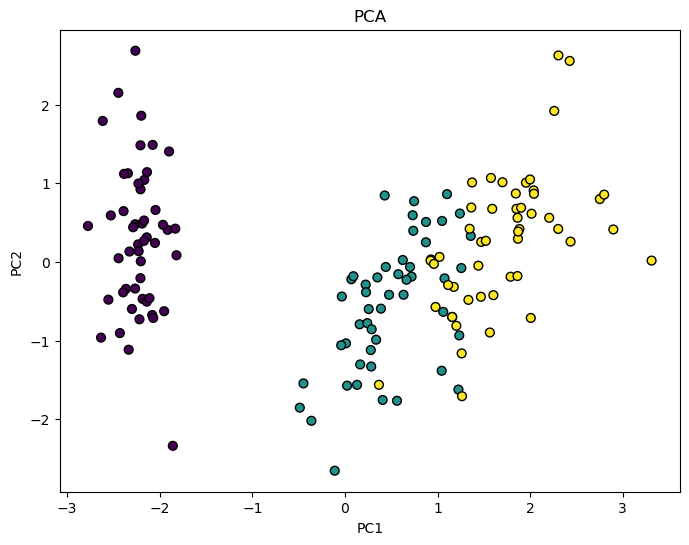

In [19]:
# 教科書のPCAの内容を、irisでやってみます。
X_scaled, df_pca, X_pca = iris.plot_pca(n_components=2)# 教師なしなので、この結果を評価してみよう!

In [20]:
X_scaled.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444


In [21]:
# StandardScalingが正しく行われていることを確認する
X_scaled.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,1.500000e+02,1.500000e+02,1.500000e+02,1.500000e+02
mean,-1.468455e-15,-1.823726e-15,-1.610564e-15,-9.473903e-16
std,1.003350e+00,1.003350e+00,1.003350e+00,1.003350e+00
min,-1.870024e+00,-2.433947e+00,-1.567576e+00,-1.447076e+00
25%,-9.006812e-01,-5.923730e-01,-1.226552e+00,-1.183812e+00
50%,-5.250608e-02,-1.319795e-01,3.364776e-01,1.325097e-01
75%,6.745011e-01,5.586108e-01,7.627583e-01,7.906707e-01
max,2.492019e+00,3.090775e+00,1.785832e+00,1.712096e+00


In [22]:
X_pca.components_# 教師なしなので、この結果を評価してみよう!

array([[ 0.52106591, -0.26934744,  0.5804131 ,  0.56485654],
       [ 0.37741762,  0.92329566,  0.02449161,  0.06694199]])

**模範解答の `components_` 期待値**:
```
array([[ 0.52106591, -0.26934744,  0.5804131 ,  0.56485654],
       [ 0.37741762,  0.92329566,  0.02449161,  0.06694199]])
```

上のセルの出力と比較してください。**完全一致するはず**です。


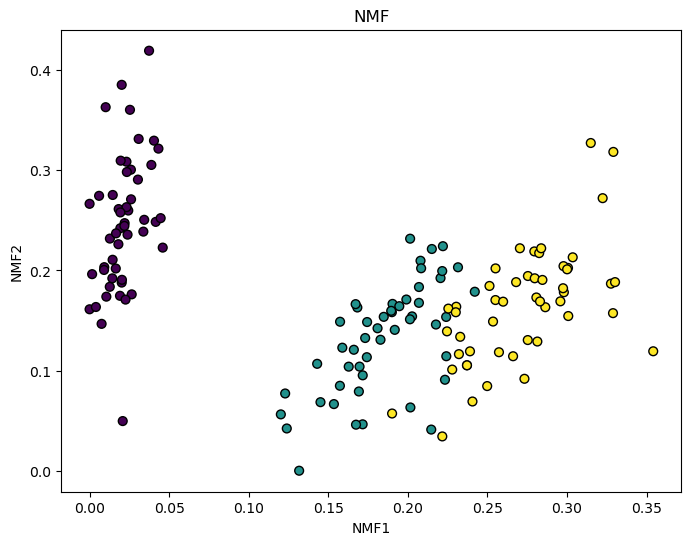

In [23]:
# 教科書のNMFの内容を、irisでやってみます。
X_scaled, df_nmf, X_nmf = iris.plot_nmf(n_components=2)# 教師なしなので、この結果を評価してみよう!

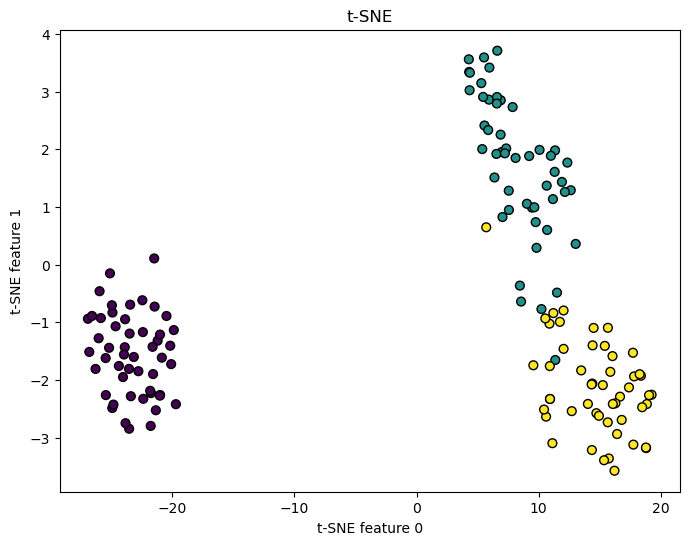

In [24]:
# スケールしていないX,ｙを使ってt-SNEを出してみる。
iris.plot_tsne()

## 7. クラスタリング(KMeans / 階層 / DBSCAN)

**チェックポイント**:

- `plot_dbscan()` のクラスタラベルが模範解答と完全一致
- `plot_dbscan(scaling=True, ...)` のクラスタラベルも完全一致


KMeans法で予測したラベル:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 2 2 2 0 2 2 2 2
 2 2 0 0 2 2 2 2 0 2 0 2 0 2 2 0 0 2 2 2 2 2 0 2 2 2 2 0 2 2 2 0 2 2 2 0 2
 2 0]

実際のラベル:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


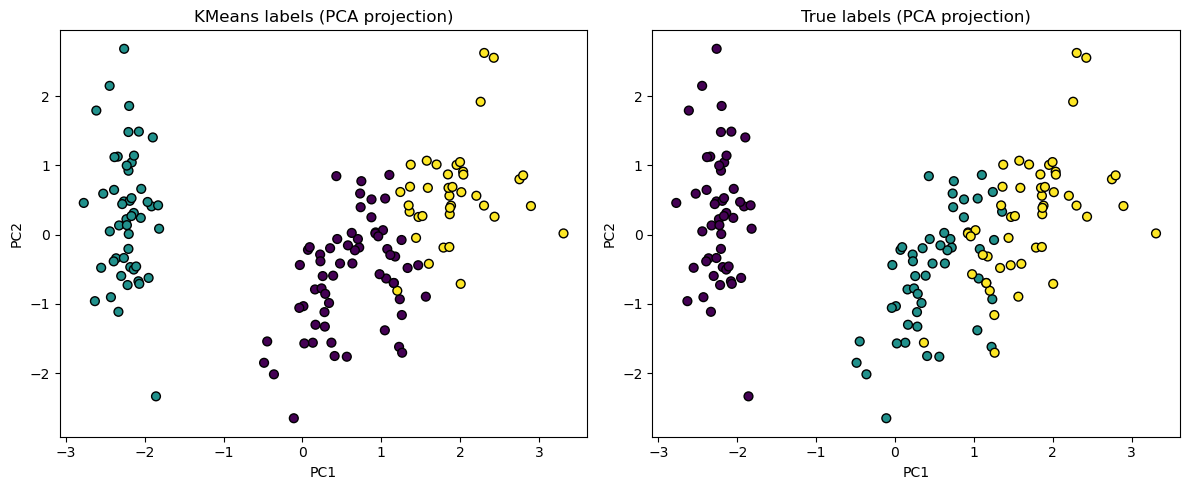

In [25]:
iris.plot_k_means()

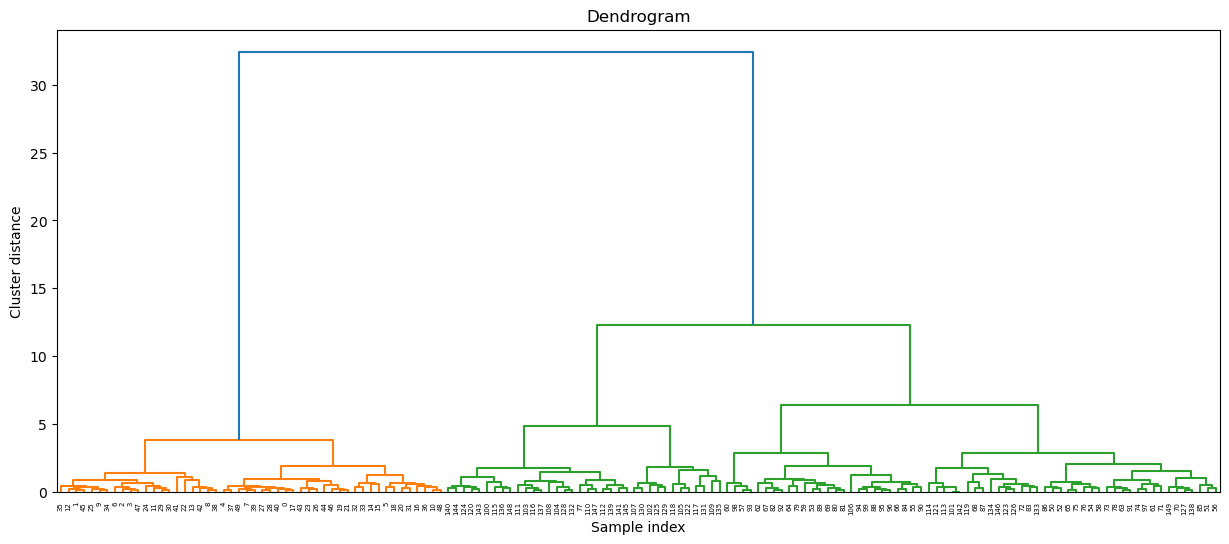

In [26]:
iris.plot_dendrogram()

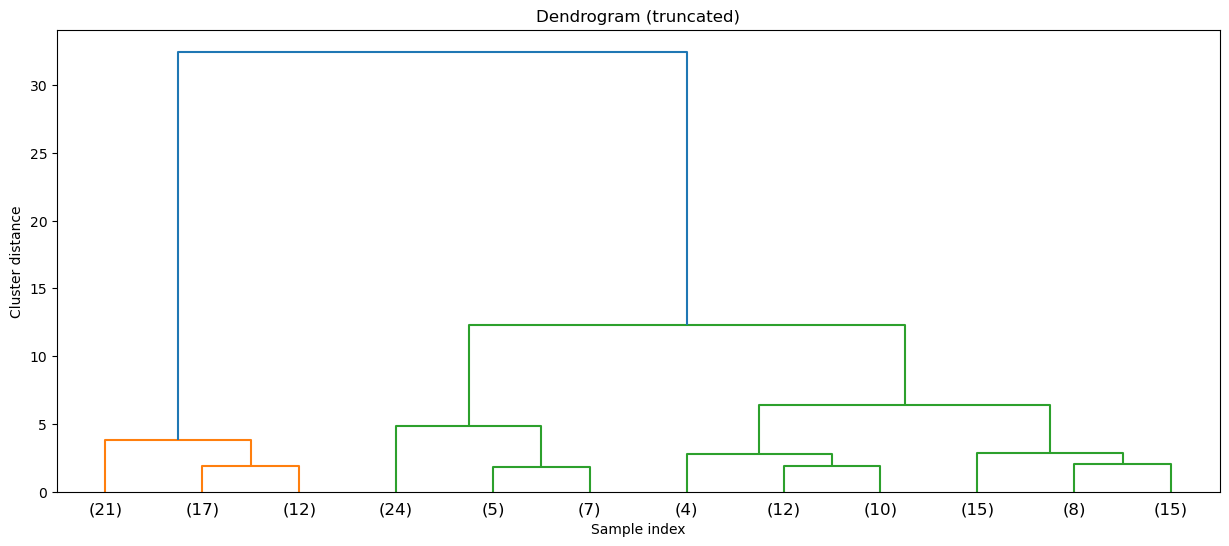

In [27]:
iris.plot_dendrogram(truncate=True)

Cluster Memberships: [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 -1  0  0  0  0  0  0
  0  0  1  1  1  1  1  1  1 -1  1  1 -1  1  1  1  1  1  1  1 -1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1 -1  1  1
  1  1 -1  1  1  1  1  1  1 -1 -1  1 -1 -1  1  1  1  1  1  1  1 -1 -1  1
  1  1 -1  1  1  1  1  1  1  1  1 -1  1  1 -1 -1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1]


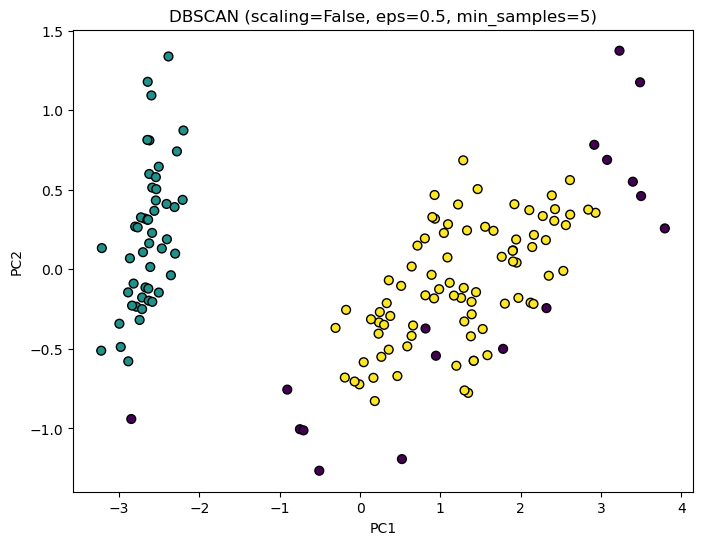

In [28]:
iris.plot_dbscan()

Cluster Memberships: [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0 -1 -1  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0 -1 -1  0  0  0  0  0  0  0 -1  0  0  0  0  0  0
  0  0  1  1  1  1  1  1 -1 -1  1 -1 -1  1 -1  1  1  1  1  1 -1  1  1  1
 -1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1 -1  1  1  1  1  1 -1  1  1
  1  1 -1  1 -1  1  1  1  1 -1 -1 -1 -1 -1  1  1  1  1 -1  1  1 -1 -1 -1
  1  1 -1  1  1 -1  1  1  1 -1 -1 -1  1  1  1 -1 -1  1  1  1  1  1  1  1
  1  1  1  1 -1  1]


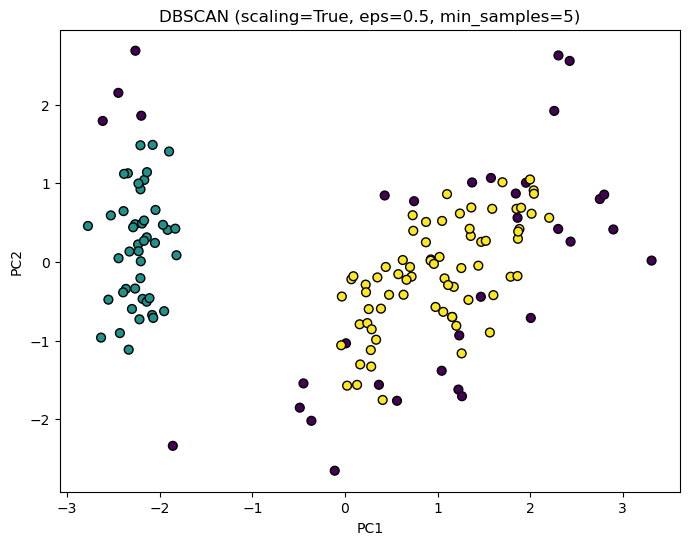

In [29]:
iris.plot_dbscan(scaling=True, eps=0.5, min_samples=5)

**模範解答の DBSCAN クラスタラベル期待値(`scaling=True` の場合)**:
```
[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0 -1 -1  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0 -1 -1  0  0  0  0  0  0  0 -1  0  0  0  0  0  0
  0  0  1  1  1  1  1  1 -1 -1  1 -1 -1  1 -1  1  1  1  1  1 -1  1  1  1
 -1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1 -1  1  1  1  1  1 -1  1  1
  1  1 -1  1 -1  1  1  1  1 -1 -1 -1 -1 -1  1  1  1  1 -1  1  1 -1 -1 -1
  1  1 -1  1  1 -1  1  1  1 -1 -1 -1  1  1  1 -1 -1  1  1  1  1  1  1  1
  1  1  1  1 -1  1]
```

**完全一致するはず**です。


## 8. バリデーション動作確認(Phase A の品質向上ポイント)

現状コードに既に組み込まれているバリデーションが機能していることを確認する。
**業務でチームが使う際にミスを早期検出する仕組み**として重要。


In [30]:
# n_neighbors に不正値を渡したときのエラー
try:
    iris.all_supervised(n_neighbors=0)
except ValueError as e:
    print("ValueError caught:", e)

ValueError caught: n_neighbors は1以上のint型です。 受け取った値: 0 (type=int)


In [31]:
# n_neighbors に bool を渡したとき(Python では bool は int の派生だが、
# 引数として渡されると意図せず通ってしまうのでブロックする)
try:
    iris.all_supervised(n_neighbors=True)
except ValueError as e:
    print("ValueError caught:", e)

ValueError caught: n_neighbors は1以上のint型です。 受け取った値: True (type=bool)


In [32]:
# n_neighbors に大きすぎる値を渡したとき
try:
    iris.all_supervised(n_neighbors=200)
except ValueError as e:
    print("ValueError caught:", e)

ValueError caught: n_neighbors が大きすぎます。 5分割交差検証では 120 以下にしてください。


In [33]:
# diag_kind に不正な文字列を渡したとき
try:
    iris.pair_plot(diag_kind="invalid")
except ValueError as e:
    print("ValueError caught:", e)

ValueError caught: diag_kind は 'auto', 'hist', 'kde', None のいずれかです。 受け取った値: 'invalid'


In [34]:
# plot_dbscan の eps が 0 以下のとき
try:
    iris.plot_dbscan(eps=0)
except ValueError as e:
    print("ValueError caught:", e)

ValueError caught: eps は正の数値です。受け取った値: 0


## 9. 動作確認まとめ

上から順に全セルを実行し、以下が満たされていることを確認:

- [ ] エラーで止まったセルが**ない**
- [ ] `pair_plot(diag_kind='kde')` が動作する
- [ ] `all_supervised` の出力ヘッダが `=== ... ===` 形式で、9 モデル分出ている
- [ ] `best_supervised` が `MLPClassifier : 0.9800` を返す
- [ ] `plot_pca` の `components_` が模範解答と完全一致
- [ ] `plot_dbscan(scaling=True, ...)` のクラスタラベルが模範解答と完全一致
- [ ] `plot_scaled_data` が DataFrame を返す(25 行 × 4 列)
- [ ] バリデーションが想定通りエラーを発生させる

次のフェーズ(Phase B)では、業務でチームが安全に使うためのリファクタを入れていく。現状の Phase A は「動く・課題要件を満たす」状態。


## 3章最終課題

KMeans, Dendrogram, DBSCAN を比較して、使い方を考察する。(模範解答ノートブックの最終セルに対応)


In [35]:
# 3章最終課題
# KMeans, Dendrogram, DBSCANを比較して、使い方を考察してください。